In [2]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
gallery_csv_path = Path(
    "/Users/jaehyunlee/Desktop/GSAPP/2026_Summer/"
    "03_ARCHA4165_ Mapping Systems/data/"
    "ny-gallery-locations-hours.csv"
)

route_geojson_path = Path(
    "/Users/jaehyunlee/Desktop/GSAPP/2026_Summer/"
    "03_ARCHA4165_ Mapping Systems/data/"
    "260714_gallery_daytrip_route.geojson"
)

census_data_path = Path(
    "/Users/jaehyunlee/Documents/GitHub/"
    "cdp-mapping-systems/content/Data/"
    "census_nyc_sp.fgb"
)

In [4]:
gallery_df = pd.read_csv(gallery_csv_path)

route_data = gpd.read_file(route_geojson_path)

census_data = gpd.read_file(census_data_path)

In [5]:
gallery_df.head()

,gallery_id,gallery,gallery_group,branch,timeline_gallery_name,neighborhood,borough,address,latitude,longitude,closing_days,opening_time,closing_time,schedule_status,data_notes,current_access_status,hours_basis,hours_text,hours_source,hours_verified_on
0,david-kordansky-gallery,David Kordansky Gallery,David Kordansky Gallery,NaN,david kordansky,Chelsea,Manhattan,"520 W 20th St, New York, NY 10011",40.746212,-74.006943,Saturday; Sunday,10:00,18:00,verified_current_seasonal,Current summer schedule; regular-season days m...,open,summer_hours,"Monday–Friday, 10:00–18:00 (summer hours)",https://www.davidkordanskygallery.com/,2026-07-14
1,gagosian-west-24th-street,Gagosian — West 24th Street,Gagosian,West 24th Street,gagosian (24),Chelsea,Manhattan,"555 W 24th St, New York, NY 10011",40.749979,-74.006152,Saturday; Sunday,10:00,18:00,verified_current_seasonal,Current schedule verified on the official loca...,open,summer_hours,"Monday–Friday, 10:00–18:00",https://gagosian.com/locations/555-west-24th-s...,2026-07-14
2,lehmann-maupin,Lehmann Maupin,Lehmann Maupin,NaN,lehmann maupin,Chelsea,Manhattan,"501 W 24th St, New York, NY 10011",40.749754,-74.004547,Saturday; Sunday,10:00,18:00,verified_current_seasonal,Official page labels these as summer hours.,open,summer_hours,"Monday–Friday, 10:00–18:00 (summer hours)",https://www.lehmannmaupin.com/about,2026-07-14
3,lisson-gallery,Lisson Gallery,Lisson Gallery,NaN,Lisson Gallery,Chelsea,Manhattan,"504-508 W 24th St, New York, NY 10011",40.749821,-74.004787,Saturday; Sunday,10:00,18:00,verified_current,Public hours apply to the New York 24th Street...,open,published_hours,"Monday–Friday, 10:00–18:00; appointments also ...",https://www.lissongallery.com/contact,2026-07-14
4,sean-kelly,Sean Kelly,Sean Kelly,NaN,Sean Kelly,Hudson Yards,Manhattan,"475 10th Ave, New York, NY 10018",40.756650,-73.999659,Saturday; Sunday,10:00,17:00,verified_current_seasonal,Current summer footer schedule; regular-season...,open,summer_hours,"Monday–Friday, 10:00–17:00 (summer hours)",https://www.skny.com/,2026-07-14


In [6]:
gallery_df.columns

Index(['gallery_id', 'gallery', 'gallery_group', 'branch',
       'timeline_gallery_name', 'neighborhood', 'borough', 'address',
       'latitude', 'longitude', 'closing_days', 'opening_time', 'closing_time',
       'schedule_status', 'data_notes', 'current_access_status', 'hours_basis',
       'hours_text', 'hours_source', 'hours_verified_on'],
      dtype='str')

In [7]:
gallery_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   gallery_id             66 non-null     str    
 1   gallery                66 non-null     str    
 2   gallery_group          66 non-null     str    
 3   branch                 19 non-null     str    
 4   timeline_gallery_name  66 non-null     str    
 5   neighborhood           66 non-null     str    
 6   borough                66 non-null     str    
 7   address                66 non-null     str    
 8   latitude               66 non-null     float64
 9   longitude              66 non-null     float64
 10  closing_days           61 non-null     str    
 11  opening_time           61 non-null     str    
 12  closing_time           61 non-null     str    
 13  schedule_status        66 non-null     str    
 14  data_notes             66 non-null     str    
 15  current_access_stat

In [8]:
route_data

,label,geometry
0,"Pace Gallery - 540 W 25th St, New York, New Yo...",POINT (-74.00492 40.74957)
1,"Petzel Gallery - 520 W 25th St, New York, New ...",POINT (-74.00422 40.74936)
2,"Yossi Milo Gallery - 245 10th Ave, New York, N...",POINT (-74.00423 40.75009)
3,"Sikkema Jenkins & Co - 530 W 22nd St, New York...",POINT (-74.0061 40.74745)
4,"David Zwirner - 537 W 20th St, New York, New Y...",POINT (-74.00728 40.74666)
5,"Jack Shainman Gallery - 513 W 20th St, New Yor...",POINT (-74.00626 40.74636)
6,Whitney Museum of American Art - 99 Gansevoort...,POINT (-74.00893 40.73966)
7,"White Columns - 91 Horatio St, New York, New Y...",POINT (-74.00863 40.73885)
8,gallery_daytrip_walking_route,"LINESTRING (-74.00425 40.75009, -74.00296 40.7..."


In [9]:
census_data.head()

,GISJOIN,Total Pop (Race/Ethnicity),Not Hispanic or Latino,Not Hispanic or Latino: White alone,Not Hispanic or Latino: Black or African American alone,Not Hispanic or Latino: American Indian and Alaska Native alone,Not Hispanic or Latino: Asian alone,Not Hispanic or Latino: Native Hawaiian and Other Pacific Islander alone,Not Hispanic or Latino: Some other race alone,Not Hispanic or Latino: Two or more races,...,"$100,000 to $124,999","$125,000 to $149,999","$150,000 to $199,999","$200,000 or more",COUNTY,TRACTCE,BLKGRPCE,Area (Sq Mi),zip_code,geometry
0,G36008101010021,3837,3817,3817,0,0,0,0,0,0,...,94,30,164,276,Queens County,101002,1,0.157620,11691,"MULTIPOLYGON (((1056895.943 157320.531, 105674..."
1,G36008101010022,2275,1803,648,350,0,794,0,0,11,...,88,0,0,204,Queens County,101002,2,0.048883,11691,"MULTIPOLYGON (((1057018.771 155993.29, 1056995..."
2,G36008101010043,2123,1506,487,766,0,243,0,0,10,...,58,0,41,28,Queens County,101004,3,0.039452,11691,"MULTIPOLYGON (((1055223.035 157038.704, 105528..."
3,G36008101010042,1464,1342,576,718,0,9,0,0,39,...,0,0,0,0,Queens County,101004,2,0.054139,11691,"MULTIPOLYGON (((1055223.035 157038.704, 105498..."
4,G36008101010032,467,195,90,76,0,12,0,0,17,...,0,0,26,0,Queens County,101003,2,0.013168,11691,"MULTIPOLYGON (((1054329.195 158352.062, 105414..."


In [10]:
print("Route CRS:", route_data.crs)
print("Census CRS:", census_data.crs)

Route CRS: EPSG:4326
Census CRS: EPSG:2263


In [11]:
required_columns = [
    "gallery",
    "neighborhood",
    "latitude",
    "longitude",
    "opening_time",
    "closing_time",
    "current_access_status",
]

missing_columns = [
    column
    for column in required_columns
    if column not in gallery_df.columns
]

if missing_columns:
    raise ValueError(
        f"The gallery CSV is missing these columns: {missing_columns}"
    )

In [12]:
gallery_df["latitude"] = pd.to_numeric(
    gallery_df["latitude"],
    errors="coerce",
)

gallery_df["longitude"] = pd.to_numeric(
    gallery_df["longitude"],
    errors="coerce",
)

In [13]:
gallery_df = gallery_df.dropna(
    subset=["latitude", "longitude"]
).copy()

In [14]:
gallery_data = gpd.GeoDataFrame(
    gallery_df,
    geometry=gpd.points_from_xy(
        gallery_df["longitude"],
        gallery_df["latitude"],
    ),
    crs="EPSG:4326",
)

In [15]:
gallery_data = gallery_data.to_crs(census_data.crs)

route_data = route_data.to_crs(census_data.crs)

In [16]:
route_points = route_data[
    route_data.geometry.geom_type.eq("Point")
].copy()

route_line = route_data[
    route_data.geometry.geom_type.eq("LineString")
].copy()

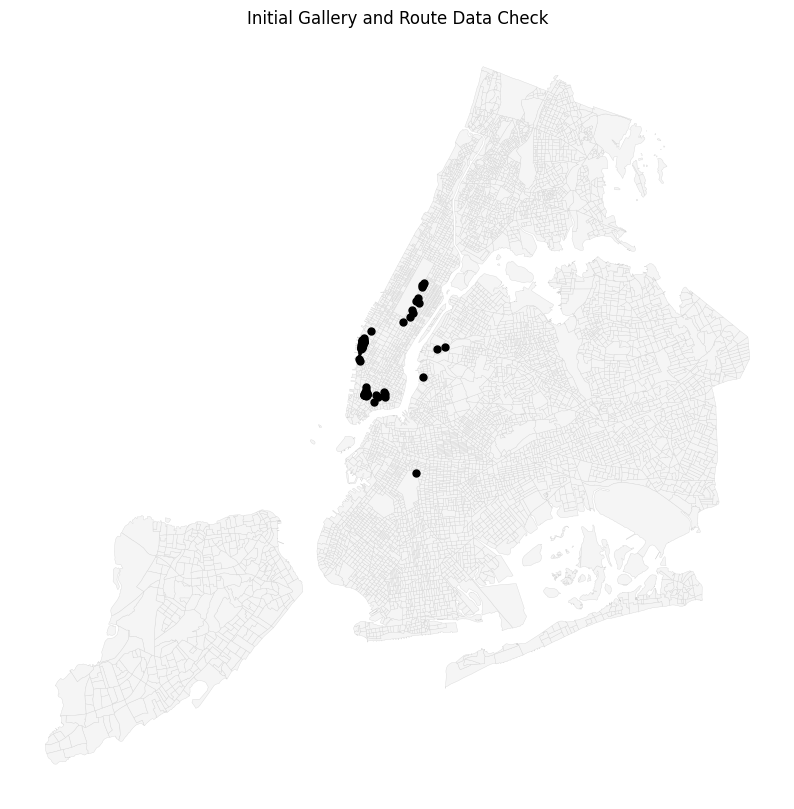

In [17]:
ax = census_data.plot(
    figsize=(10, 10),
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.25,
)

gallery_data.plot(
    ax=ax,
    color="black",
    markersize=25,
)

route_line.plot(
    ax=ax,
    color="black",
    linewidth=2,
)

ax.set_title("Initial Gallery and Route Data Check")
ax.set_axis_off()

plt.show()

In [18]:
neighborhood_counts = (
    gallery_data["neighborhood"]
    .value_counts()
    .sort_values()
)

neighborhood_counts

neighborhood
Hudson Yards             1
West Village             1
Meatpacking District     1
Prospect Heights         1
Greenpoint               1
Midtown East             1
Chinatown                2
Long Island City         2
SoHo                     2
Lower East Side          4
Upper East Side         10
Tribeca                 17
Chelsea                 23
Name: count, dtype: int64

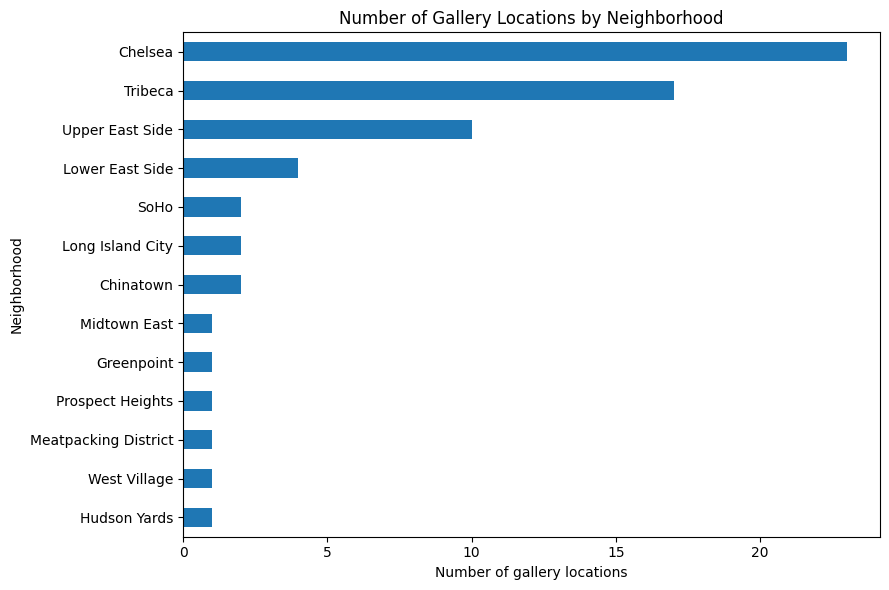

In [19]:
ax = neighborhood_counts.plot(
    kind="barh",
    figsize=(9, 6),
)

ax.set_title("Number of Gallery Locations by Neighborhood")
ax.set_xlabel("Number of gallery locations")
ax.set_ylabel("Neighborhood")

plt.tight_layout()
plt.show()

In [20]:
minx, miny, maxx, maxy = gallery_data.total_bounds

padding = 5000

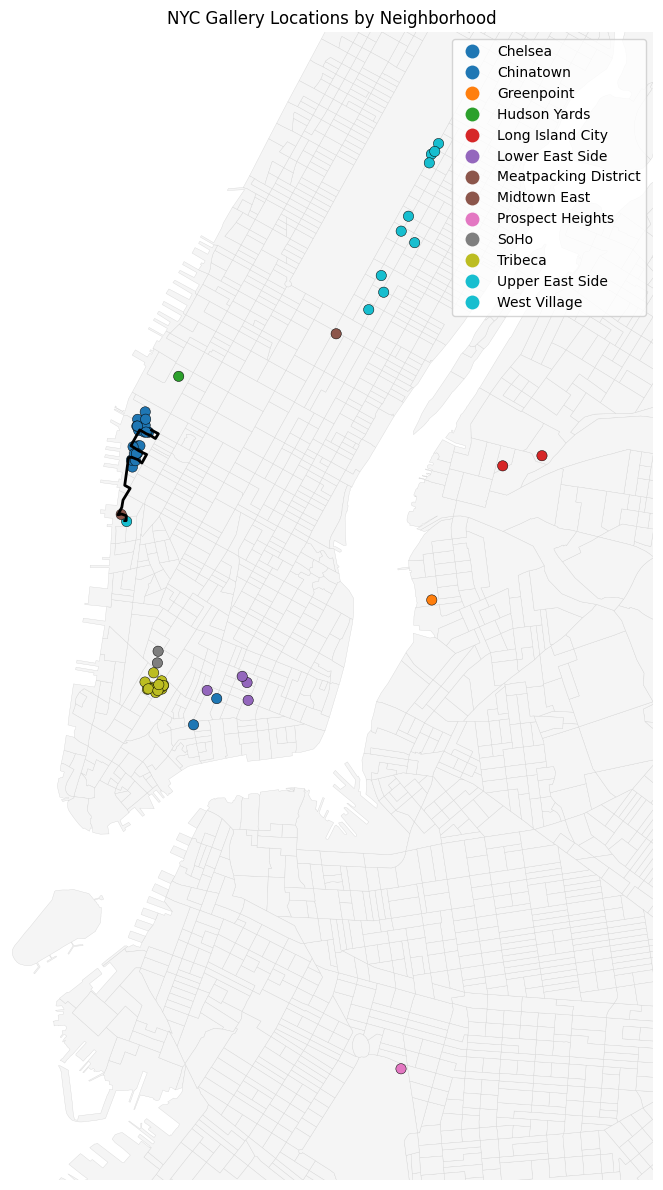

In [21]:
ax = census_data.plot(
    figsize=(12, 12),
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.25,
)

gallery_data.plot(
    ax=ax,
    column="neighborhood",
    categorical=True,
    legend=True,
    markersize=55,
    edgecolor="black",
    linewidth=0.35,
)

route_line.plot(
    ax=ax,
    color="black",
    linewidth=2,
    label="Planned day-trip route",
)

ax.set_xlim(
    minx - padding,
    maxx + padding,
)

ax.set_ylim(
    miny - padding,
    maxy + padding,
)

ax.set_title("NYC Gallery Locations by Neighborhood")
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [22]:
def time_to_decimal(time_value):
    if pd.isna(time_value) or str(time_value).strip() == "":
        return np.nan

    hour, minute = str(time_value).split(":")

    return int(hour) + int(minute) / 60

In [23]:
gallery_data["opening_hour"] = gallery_data[
    "opening_time"
].apply(time_to_decimal)

gallery_data["closing_hour"] = gallery_data[
    "closing_time"
].apply(time_to_decimal)

In [24]:
gallery_data["daily_open_hours"] = (
    gallery_data["closing_hour"]
    - gallery_data["opening_hour"]
)

In [25]:
gallery_data[
    [
        "gallery",
        "opening_time",
        "closing_time",
        "daily_open_hours",
        "current_access_status",
    ]
].head(10)

,gallery,opening_time,closing_time,daily_open_hours,current_access_status
0,David Kordansky Gallery,10:00,18:00,8.0,open
1,Gagosian — West 24th Street,10:00,18:00,8.0,open
2,Lehmann Maupin,10:00,18:00,8.0,open
3,Lisson Gallery,10:00,18:00,8.0,open
4,Sean Kelly,10:00,17:00,7.0,open
5,David Zwirner — West 19th Street,10:00,18:00,8.0,open
6,David Zwirner — West 20th Street,NaN,NaN,NaN,temporarily_closed
7,Matthew Marks Gallery — West 22nd Street,10:00,18:00,8.0,temporarily_closed
8,Matthew Marks Gallery — West 24th Street,10:00,18:00,8.0,temporarily_closed
9,Petzel,10:00,18:00,8.0,open


In [26]:
gallery_data["daily_open_hours"].describe()

count    61.000000
mean      7.729235
std       2.255530
min       5.000000
25%       7.000000
50%       8.000000
75%       8.000000
max      23.983333
Name: daily_open_hours, dtype: float64

In [27]:
open_gallery_data = gallery_data[
    gallery_data["current_access_status"].eq("open")
    & gallery_data["daily_open_hours"].notna()
].copy()

In [28]:
print(
    "All gallery locations:",
    len(gallery_data),
)

print(
    "Open galleries with usable hours:",
    len(open_gallery_data),
)

All gallery locations: 66
Open galleries with usable hours: 59


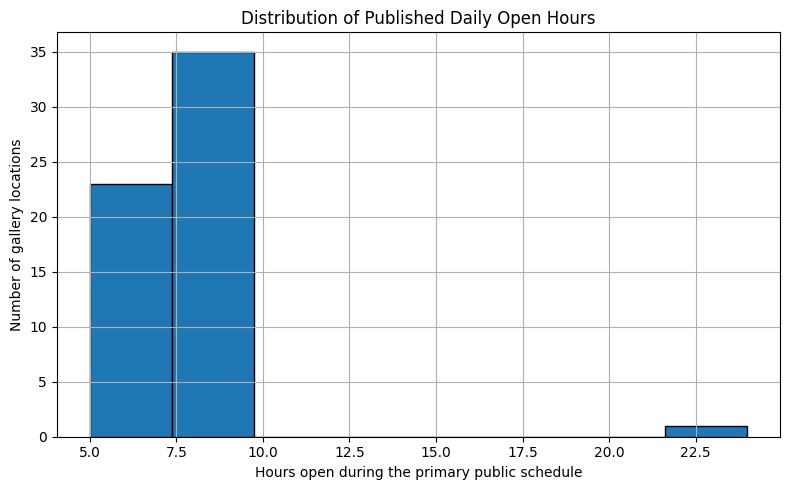

In [29]:
ax = open_gallery_data[
    "daily_open_hours"
].hist(
    bins=8,
    figsize=(8, 5),
    edgecolor="black",
)

ax.set_title("Distribution of Published Daily Open Hours")
ax.set_xlabel("Hours open during the primary public schedule")
ax.set_ylabel("Number of gallery locations")

plt.tight_layout()
plt.show()

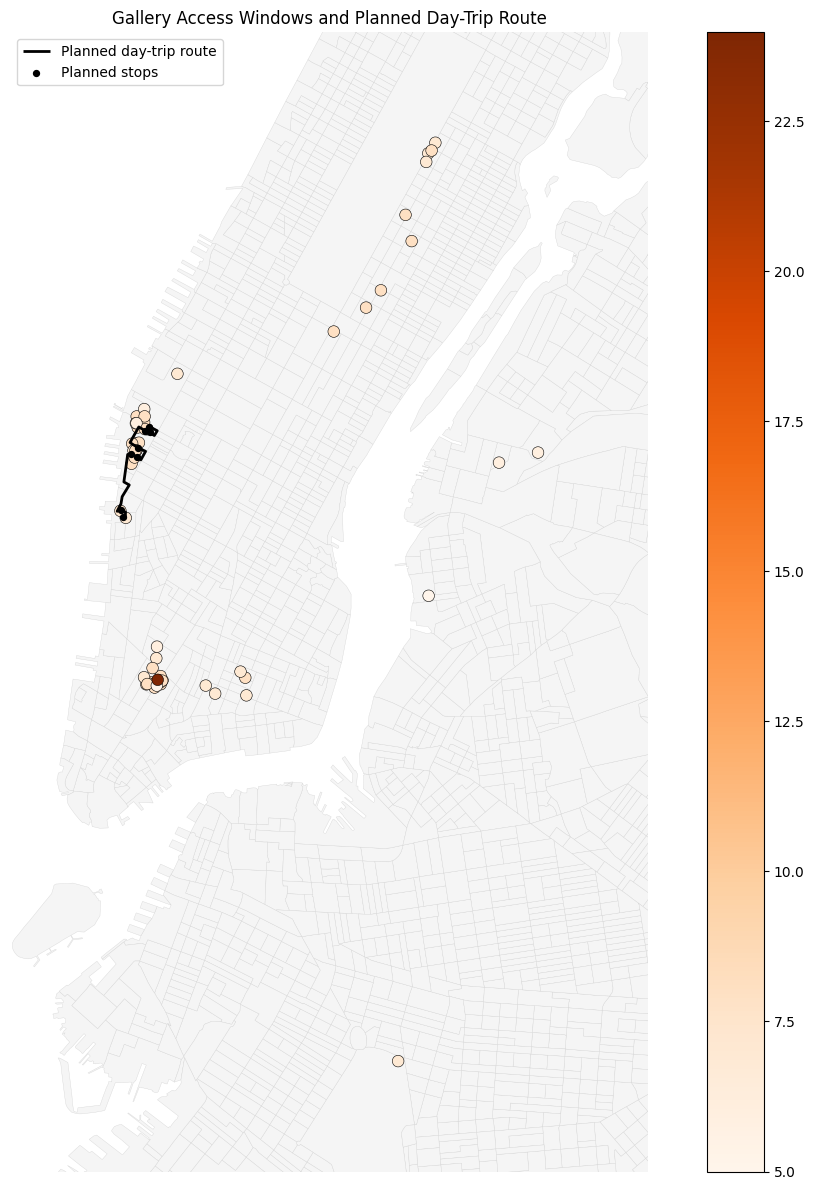

In [30]:
ax = census_data.plot(
    figsize=(12, 12),
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.25,
)

open_gallery_data.plot(
    ax=ax,
    column="daily_open_hours",
    cmap="Oranges",
    legend=True,
    markersize=70,
    edgecolor="black",
    linewidth=0.4,
)

route_line.plot(
    ax=ax,
    color="black",
    linewidth=2,
    label="Planned day-trip route",
)

route_points.plot(
    ax=ax,
    color="black",
    markersize=18,
    label="Planned stops",
)

ax.set_xlim(
    minx - padding,
    maxx + padding,
)

ax.set_ylim(
    miny - padding,
    maxy + padding,
)

ax.set_title("Gallery Access Windows and Planned Day-Trip Route")
ax.set_axis_off()

ax.legend(
    loc="upper left",
)

plt.tight_layout()
plt.show()

In [31]:
neighborhood_hours = (
    open_gallery_data
    .groupby("neighborhood")["daily_open_hours"]
    .mean()
    .sort_values()
)

neighborhood_hours

neighborhood
Greenpoint              5.000000
Long Island City        6.000000
SoHo                    6.500000
Chinatown               7.000000
Hudson Yards            7.000000
Prospect Heights        7.000000
West Village            7.000000
Lower East Side         7.250000
Meatpacking District    7.500000
Upper East Side         7.625000
Chelsea                 7.650000
Midtown East            8.000000
Tribeca                 8.686458
Name: daily_open_hours, dtype: float64

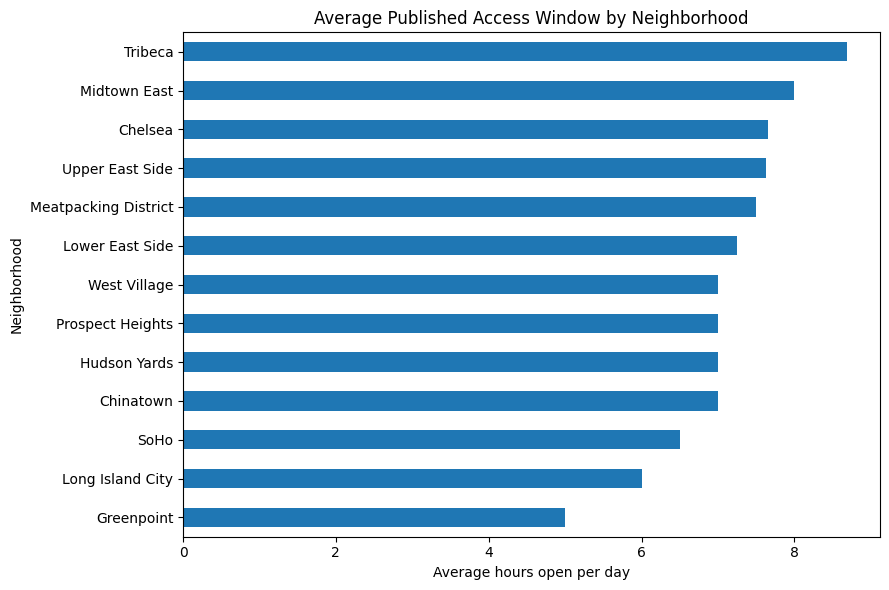

In [32]:
ax = neighborhood_hours.plot(
    kind="barh",
    figsize=(9, 6),
)

ax.set_title("Average Published Access Window by Neighborhood")
ax.set_xlabel("Average hours open per day")
ax.set_ylabel("Neighborhood")

plt.tight_layout()
plt.show()

In [33]:
open_gallery_data[
    [
        "gallery",
        "neighborhood",
        "opening_time",
        "closing_time",
        "daily_open_hours",
        "hours_text",
    ]
].sort_values(
    "daily_open_hours",
    ascending=False,
).head(10)

,gallery,neighborhood,opening_time,closing_time,daily_open_hours,hours_text
54,WINDOW — Anton Kern Gallery,Tribeca,00:00,23:59,23.983333,"On view 24 hours a day, 7 days a week from the..."
0,David Kordansky Gallery,Chelsea,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00 (summer hours)"
58,Sprüth Magers,Upper East Side,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00; appointments avail..."
57,Gladstone Gallery — East 64th Street,Upper East Side,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00"
56,Gagosian — Park Avenue,Upper East Side,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00"
51,P.P.O.W,Tribeca,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00"
30,Perrotin,Lower East Side,10:00,18:00,8.000000,"Tuesday–Saturday, 10:00–18:00"
50,Mendes Wood DM,Tribeca,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00"
49,Marian Goodman Gallery,Tribeca,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00 beginning July 6, 2026"
1,Gagosian — West 24th Street,Chelsea,10:00,18:00,8.000000,"Monday–Friday, 10:00–18:00"


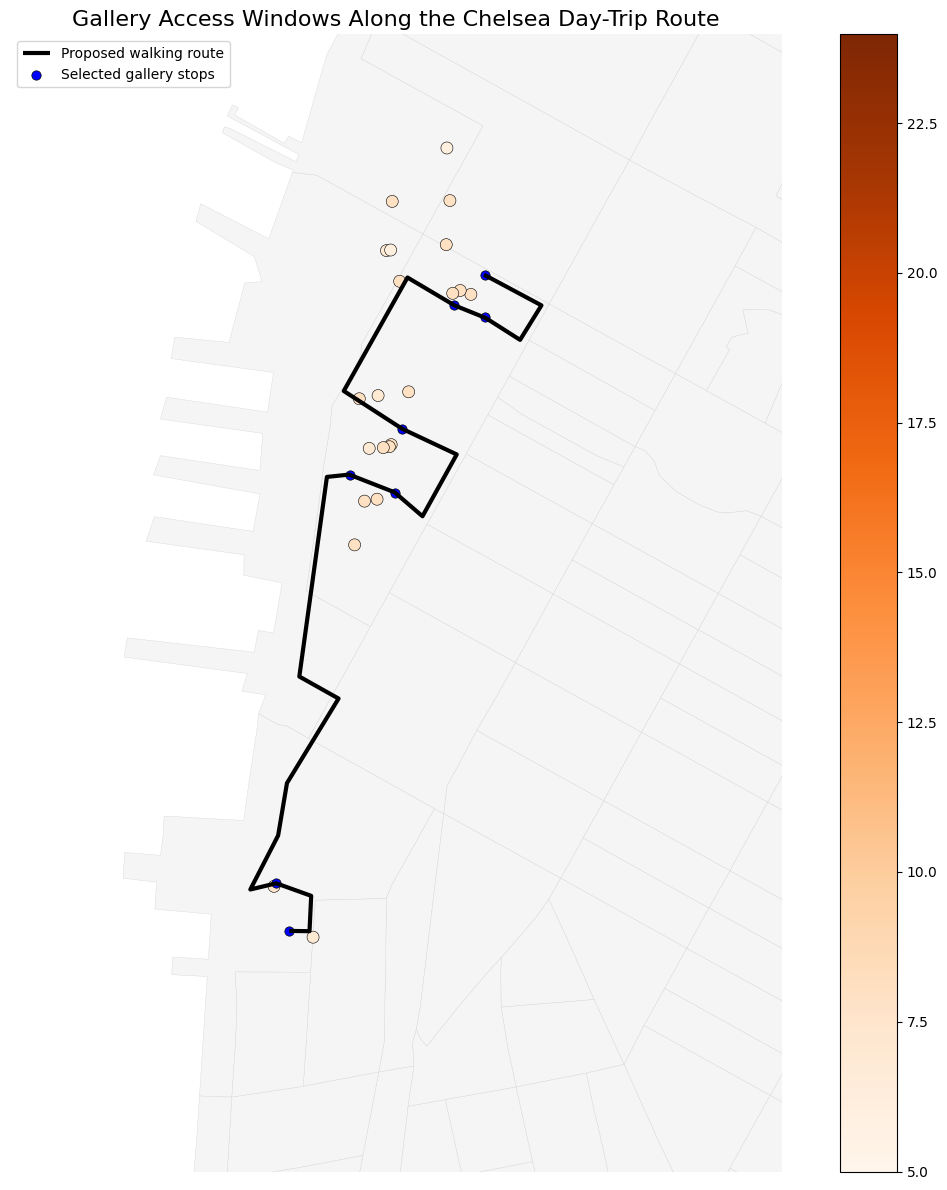

In [34]:
# Get the geographic boundary of the route
route_minx, route_miny, route_maxx, route_maxy = route_data.total_bounds

# Add space around the route so the map is not cropped too tightly
route_padding = 1500

# Create the census base map
ax = census_data.plot(
    figsize=(12, 12),
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.25,
)

# Plot all galleries located around the route
open_gallery_data.plot(
    ax=ax,
    column="daily_open_hours",
    cmap="Oranges",
    legend=True,
    markersize=75,
    edgecolor="black",
    linewidth=0.4,
)

# Plot the proposed route line
route_line.plot(
    ax=ax,
    color="black",
    linewidth=3,
    label="Proposed walking route",
)

# Plot the gallery stops included in the GeoJSON
route_points.plot(
    ax=ax,
    color="blue",
    markersize=45,
    edgecolor="black",
    linewidth=0.5,
    label="Selected gallery stops",
)

# Limit the horizontal map extent to the route area
ax.set_xlim(
    route_minx - route_padding,
    route_maxx + route_padding,
)

# Limit the vertical map extent to the route area
ax.set_ylim(
    route_miny - route_padding,
    route_maxy + route_padding,
)

# Add a map title
ax.set_title(
    "Gallery Access Windows Along the Chelsea Day-Trip Route",
    fontsize=16,
)

# Remove coordinate-axis labels
ax.set_axis_off()

# Display the route and stop legend
ax.legend(
    loc="upper left",
)

# Improve spacing around the figure
plt.tight_layout()

# Display the map
plt.show()